In [1]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G_0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

In [2]:
# fit values

GN_G0: float = 0.18877592218372993
Delta_meV: float = 0.19345000789195935
gamma_meV: float = 0.005066874981090785
eta: float = 0.002173
nu_GHz: float = 13.6

eta = 0.002173  # (3)
Aoff_mV = -6.2e-3  # (13) mV
Tbase_K = 0.0806  # (46) K
Toff_K = -0.685  # (194) K
alphaT = 2.6811  # (458)

In [3]:
# # import from pickle

# HOME_DIR = "/Users/oliver/Documents/cryolab/p5control-bluefors-evaluation"
# sys.path.append(HOME_DIR)

# from utilities.ivplot import IVPlot

# importlib.reload(sys.modules["utilities.ivplot"])

# eva = IVPlot()
# eva.title = f"amplitude at 13.6GHz"
# eva.sub_folder = (
#     "/Users/oliver/Documents/cryolab/superconductivity/evaluation/TB irradiation/data/"
# )
# eva.loadData()

# Vbias_mV = eva.mapped["voltage_axis"] * 1e3
# Ibias_nA = eva.mapped["current_axis"] * 1e9
# Aout_mV = eva.mapped["y_axis"] * 1e3
# dGexp_G0 = eva.up_sweep["differential_conductance"]
# dRexp_R0 = eva.up_sweep["differential_resistance"]
# Iexp_nA = eva.up_sweep["current"] * 1e9

In [4]:
# no analysis
psdanalysis = None
offsetanalysis = dict(
    Voff_mV=np.array(
        [
            -0.0126,
            -0.0126,
            -0.0144,
            -0.0146,
            -0.0142,
            -0.015,
            -0.0144,
            -0.0146,
            -0.0144,
            -0.0144,
            -0.015,
            -0.0144,
            -0.0148,
            -0.0148,
            -0.0146,
            -0.0146,
            -0.0148,
            -0.0144,
            -0.0146,
            -0.0148,
            -0.0146,
            -0.015,
            -0.0146,
            -0.0152,
            -0.0148,
            -0.0142,
            -0.0148,
            -0.0144,
            -0.0154,
            -0.0146,
            -0.0144,
            -0.015,
            -0.0148,
            -0.0146,
            -0.0146,
            -0.0152,
            -0.0148,
            -0.0142,
            -0.015,
            -0.0146,
            -0.0146,
            -0.0146,
            -0.0148,
            -0.0138,
            -0.0148,
            -0.0148,
            -0.0144,
            -0.0146,
            -0.0144,
            -0.0142,
            -0.0144,
            -0.0144,
            -0.0138,
            -0.014,
            -0.0142,
            -0.0134,
            -0.0132,
            -0.0134,
            -0.0132,
            -0.0138,
            -0.0132,
            -0.013,
            -0.0128,
            -0.0124,
            -0.013,
            -0.013,
            -0.0132,
            -0.0128,
            -0.0128,
            -0.0128,
            -0.0122,
            -0.0126,
            -0.0122,
            -0.012,
            -0.0116,
            -0.0118,
            -0.0112,
            -0.011,
            -0.0108,
            -0.0106,
            -0.0104,
            -0.0104,
            -0.01,
            -0.0094,
            -0.0092,
            -0.009,
            -0.0098,
            -0.0088,
            -0.0092,
            -0.0086,
            -0.0084,
            -0.0084,
            -0.008,
            -0.0086,
            -0.0084,
            -0.0082,
            -0.0076,
            -0.0076,
            -0.0078,
            -0.0074,
            -0.0074,
            -0.0074,
            -0.0072,
            -0.0066,
            -0.0068,
            -0.0068,
            -0.0074,
            -0.007,
            -0.0056,
            -0.0064,
            -0.0058,
            -0.0058,
            -0.0062,
            -0.006,
            -0.0056,
            -0.0054,
            -0.0054,
            -0.0052,
            -0.0054,
            -0.0058,
            -0.0058,
            -0.0052,
            -0.0062,
            -0.0052,
            -0.0048,
            -0.0056,
            -0.0058,
            -0.006,
            -0.0072,
            -0.0064,
            -0.006,
            -0.0068,
            -0.0066,
            -0.0064,
            -0.0064,
            -0.0066,
            -0.0072,
            -0.007,
            -0.007,
            -0.0064,
            -0.0064,
            -0.006,
            -0.006,
        ]
    ),
    Ioff_nA=np.array(
        [
            -2.80000000e-02,
            -2.80000000e-02,
            -5.00000000e-03,
            -3.00000000e-03,
            -4.00000000e-03,
            -3.00000000e-03,
            -2.00000000e-03,
            -3.00000000e-03,
            -1.00000000e-03,
            -6.00000000e-03,
            -5.00000000e-03,
            -1.00000000e-03,
            5.55111512e-17,
            4.00000000e-03,
            -2.00000000e-03,
            2.00000000e-03,
            5.00000000e-03,
            3.00000000e-03,
            2.00000000e-03,
            1.00000000e-03,
            3.00000000e-03,
            5.55111512e-17,
            6.00000000e-03,
            -1.00000000e-03,
            -4.00000000e-03,
            5.55111512e-17,
            1.00000000e-03,
            -4.00000000e-03,
            1.00000000e-03,
            2.00000000e-03,
            -1.00000000e-03,
            -1.00000000e-03,
            -5.00000000e-03,
            -4.00000000e-03,
            -5.00000000e-03,
            -4.00000000e-03,
            3.00000000e-03,
            -4.00000000e-03,
            -3.00000000e-03,
            2.00000000e-03,
            -4.00000000e-03,
            3.00000000e-03,
            5.55111512e-17,
            3.00000000e-03,
            -3.00000000e-03,
            5.55111512e-17,
            5.55111512e-17,
            -2.00000000e-03,
            5.55111512e-17,
            -1.00000000e-03,
            1.00000000e-03,
            3.00000000e-03,
            -2.00000000e-03,
            -6.00000000e-03,
            -1.00000000e-02,
            -3.00000000e-03,
            -2.00000000e-03,
            -1.30000000e-02,
            -1.00000000e-02,
            -6.00000000e-03,
            -1.20000000e-02,
            -1.50000000e-02,
            -1.40000000e-02,
            -2.10000000e-02,
            -1.90000000e-02,
            -1.40000000e-02,
            -1.60000000e-02,
            -2.10000000e-02,
            -2.20000000e-02,
            -2.00000000e-02,
            -2.20000000e-02,
            -2.70000000e-02,
            -3.30000000e-02,
            -3.30000000e-02,
            -3.50000000e-02,
            -4.30000000e-02,
            -3.80000000e-02,
            -4.30000000e-02,
            -4.60000000e-02,
            -4.90000000e-02,
            -4.90000000e-02,
            -5.90000000e-02,
            -6.20000000e-02,
            -4.90000000e-02,
            -8.00000000e-02,
            -7.90000000e-02,
            -7.50000000e-02,
            -7.10000000e-02,
            -8.70000000e-02,
            -8.50000000e-02,
            -7.60000000e-02,
            -9.00000000e-02,
            -8.30000000e-02,
            -9.50000000e-02,
            -9.00000000e-02,
            -8.90000000e-02,
            -9.10000000e-02,
            -8.30000000e-02,
            -7.50000000e-02,
            -7.90000000e-02,
            -7.90000000e-02,
            -7.80000000e-02,
            -8.90000000e-02,
            -9.20000000e-02,
            -6.80000000e-02,
            -8.70000000e-02,
            -8.00000000e-02,
            -8.30000000e-02,
            -7.90000000e-02,
            -7.80000000e-02,
            -7.30000000e-02,
            -8.10000000e-02,
            -8.30000000e-02,
            -7.10000000e-02,
            -8.60000000e-02,
            -7.70000000e-02,
            -8.80000000e-02,
            -9.10000000e-02,
            -9.50000000e-02,
            -9.80000000e-02,
            -9.50000000e-02,
            -1.08000000e-01,
            -1.15000000e-01,
            -1.24000000e-01,
            -1.24000000e-01,
            -1.20000000e-01,
            -1.09000000e-01,
            -1.09000000e-01,
            -1.05000000e-01,
            -1.03000000e-01,
            -1.13000000e-01,
            -1.10000000e-01,
            -8.80000000e-02,
            -8.90000000e-02,
            -9.60000000e-02,
            -1.13000000e-01,
            -1.07000000e-01,
            -1.24000000e-01,
            -1.21000000e-01,
            -1.18000000e-01,
            -1.31000000e-01,
            -1.23000000e-01,
            -1.39000000e-01,
        ]
    ),
)

In [5]:
# get data
from superconductivity.evaluation import (
    get_status_keys,
    get_measurement_keys,
    FileSpec,
)

filespec = FileSpec(
    h5path="OI-25c-09 2025-05-02 unbroken stripline irradiation studies 0.hdf5",
    location="/Users/oliver/Documents/measurement data/25 04 OI-25c-09",
    measurement="vna_amplitudes_18.3000GHz",
)

measurement_keys = get_measurement_keys(filespec=filespec)
status_keys = get_status_keys(filespec=filespec)

In [6]:
# get traces
from superconductivity.evaluation import FileSpec
from superconductivity.evaluation import KeysSpec
from superconductivity.evaluation import TraceSpec
from superconductivity.evaluation import get_keys
from superconductivity.evaluation import get_traces


keysspec = KeysSpec(
    strip0="GHz_",
    strip1="V",
    remove_key="no_irradiation",
    add_key=[
        ("no_irradiation", 0.0),
        ("no_irradiation", 0.005),
    ],
    limits=(None, None),
    norm=1e-3,
    label="Aout_mV",
    html_label="<i>A</i><sub>out</sub> (mV)",
)

tracespec = TraceSpec(
    amp_voltage=1000,
    amp_current=1000,
    trigger_values=1,
    skip=5,
)

mkeys = filespec.mkeys()
skeys = filespec.skeys()

keys = get_keys(
    filespec=filespec,
    keysspec=keysspec,
)

traces = get_traces(
    filespec=filespec,
    keysspec=keysspec,
    tracespec=tracespec,
)

In [7]:
# psd analysis
from superconductivity.evaluation import PSDSpec
from superconductivity.evaluation import psd_analysis

psdspec = PSDSpec(
    detrend=True,
)

psdanalysis = psd_analysis(
    traces=traces,
    spec=psdspec,
)

In [8]:
# # analysis
# from superconductivity.evaluation import OffsetSpec
# from superconductivity.evaluation import offset_analysis

# offsetspec = OffsetSpec(
#     Vbins_mV=np.linspace(-0.5, 0.5, 51),
#     Ibins_nA=np.linspace(-5.0, 5.0, 181),
#     Voff_mV=np.linspace(-0.045, 0.045, 451),
#     Ioff_nA=np.linspace(-0.35, 0.35, 701),
#     nu_Hz=13.7,
#     upsample=10,
# )

# offsetanalysis = offset_analysis(
#     traces=traces,
#     spec=offsetspec,
# )

In [9]:
# # sampling

# from superconductivity.evaluation import SamplingSpec
# from superconductivity.evaluation import sample

# samplingspec = SamplingSpec(
#     Vbins_mV=np.linspace(-1.6, 1.6, 1601),
#     Ibins_nA=np.linspace(-30.0, 30.0, 2001),
#     nu_Hz=43.7,
#     N_up=1000,
#     median_bins=3,
#     sigma_bins=2.0,
# )

# samples = sample(
#     traces=traces,
#     samplingspec=samplingspec,
#     offsetanalysis=offsetanalysis,
# )

In [10]:
# eva gui
from superconductivity.gui import gui

importlib.reload(sys.modules["superconductivity.gui"])

app = gui(
    traces=traces,
    filespec=filespec,
    keysspec=keysspec,
    tracespec=tracespec,
    keys=keys,
    psdspec=psdspec,
    psdanalysis=psdanalysis,
    # offsetspec=offsetspec,
    # offsetanalysis=offsetanalysis,
    # samples=samples,
    # samplingspec=samplingspec,
)

Launching server at http://localhost:61424


In [38]:
from superconductivity.models.mar import get_Imar_nA

V_mV = np.linspace(-1, 1, 1001)
tau = (0.999, 0.8, 0.5, 0.4)
I_nA, Ix_nA = get_Imar_nA(
    V_mV=V_mV,
    tau=tau,
    Delta_meV=(0, 0.18),
    gamma_meV=0,
    tau_resolved=False,
    charge_resolved=True,
)

ValueError: could not broadcast input array from shape (1001,3) into shape (3003,)

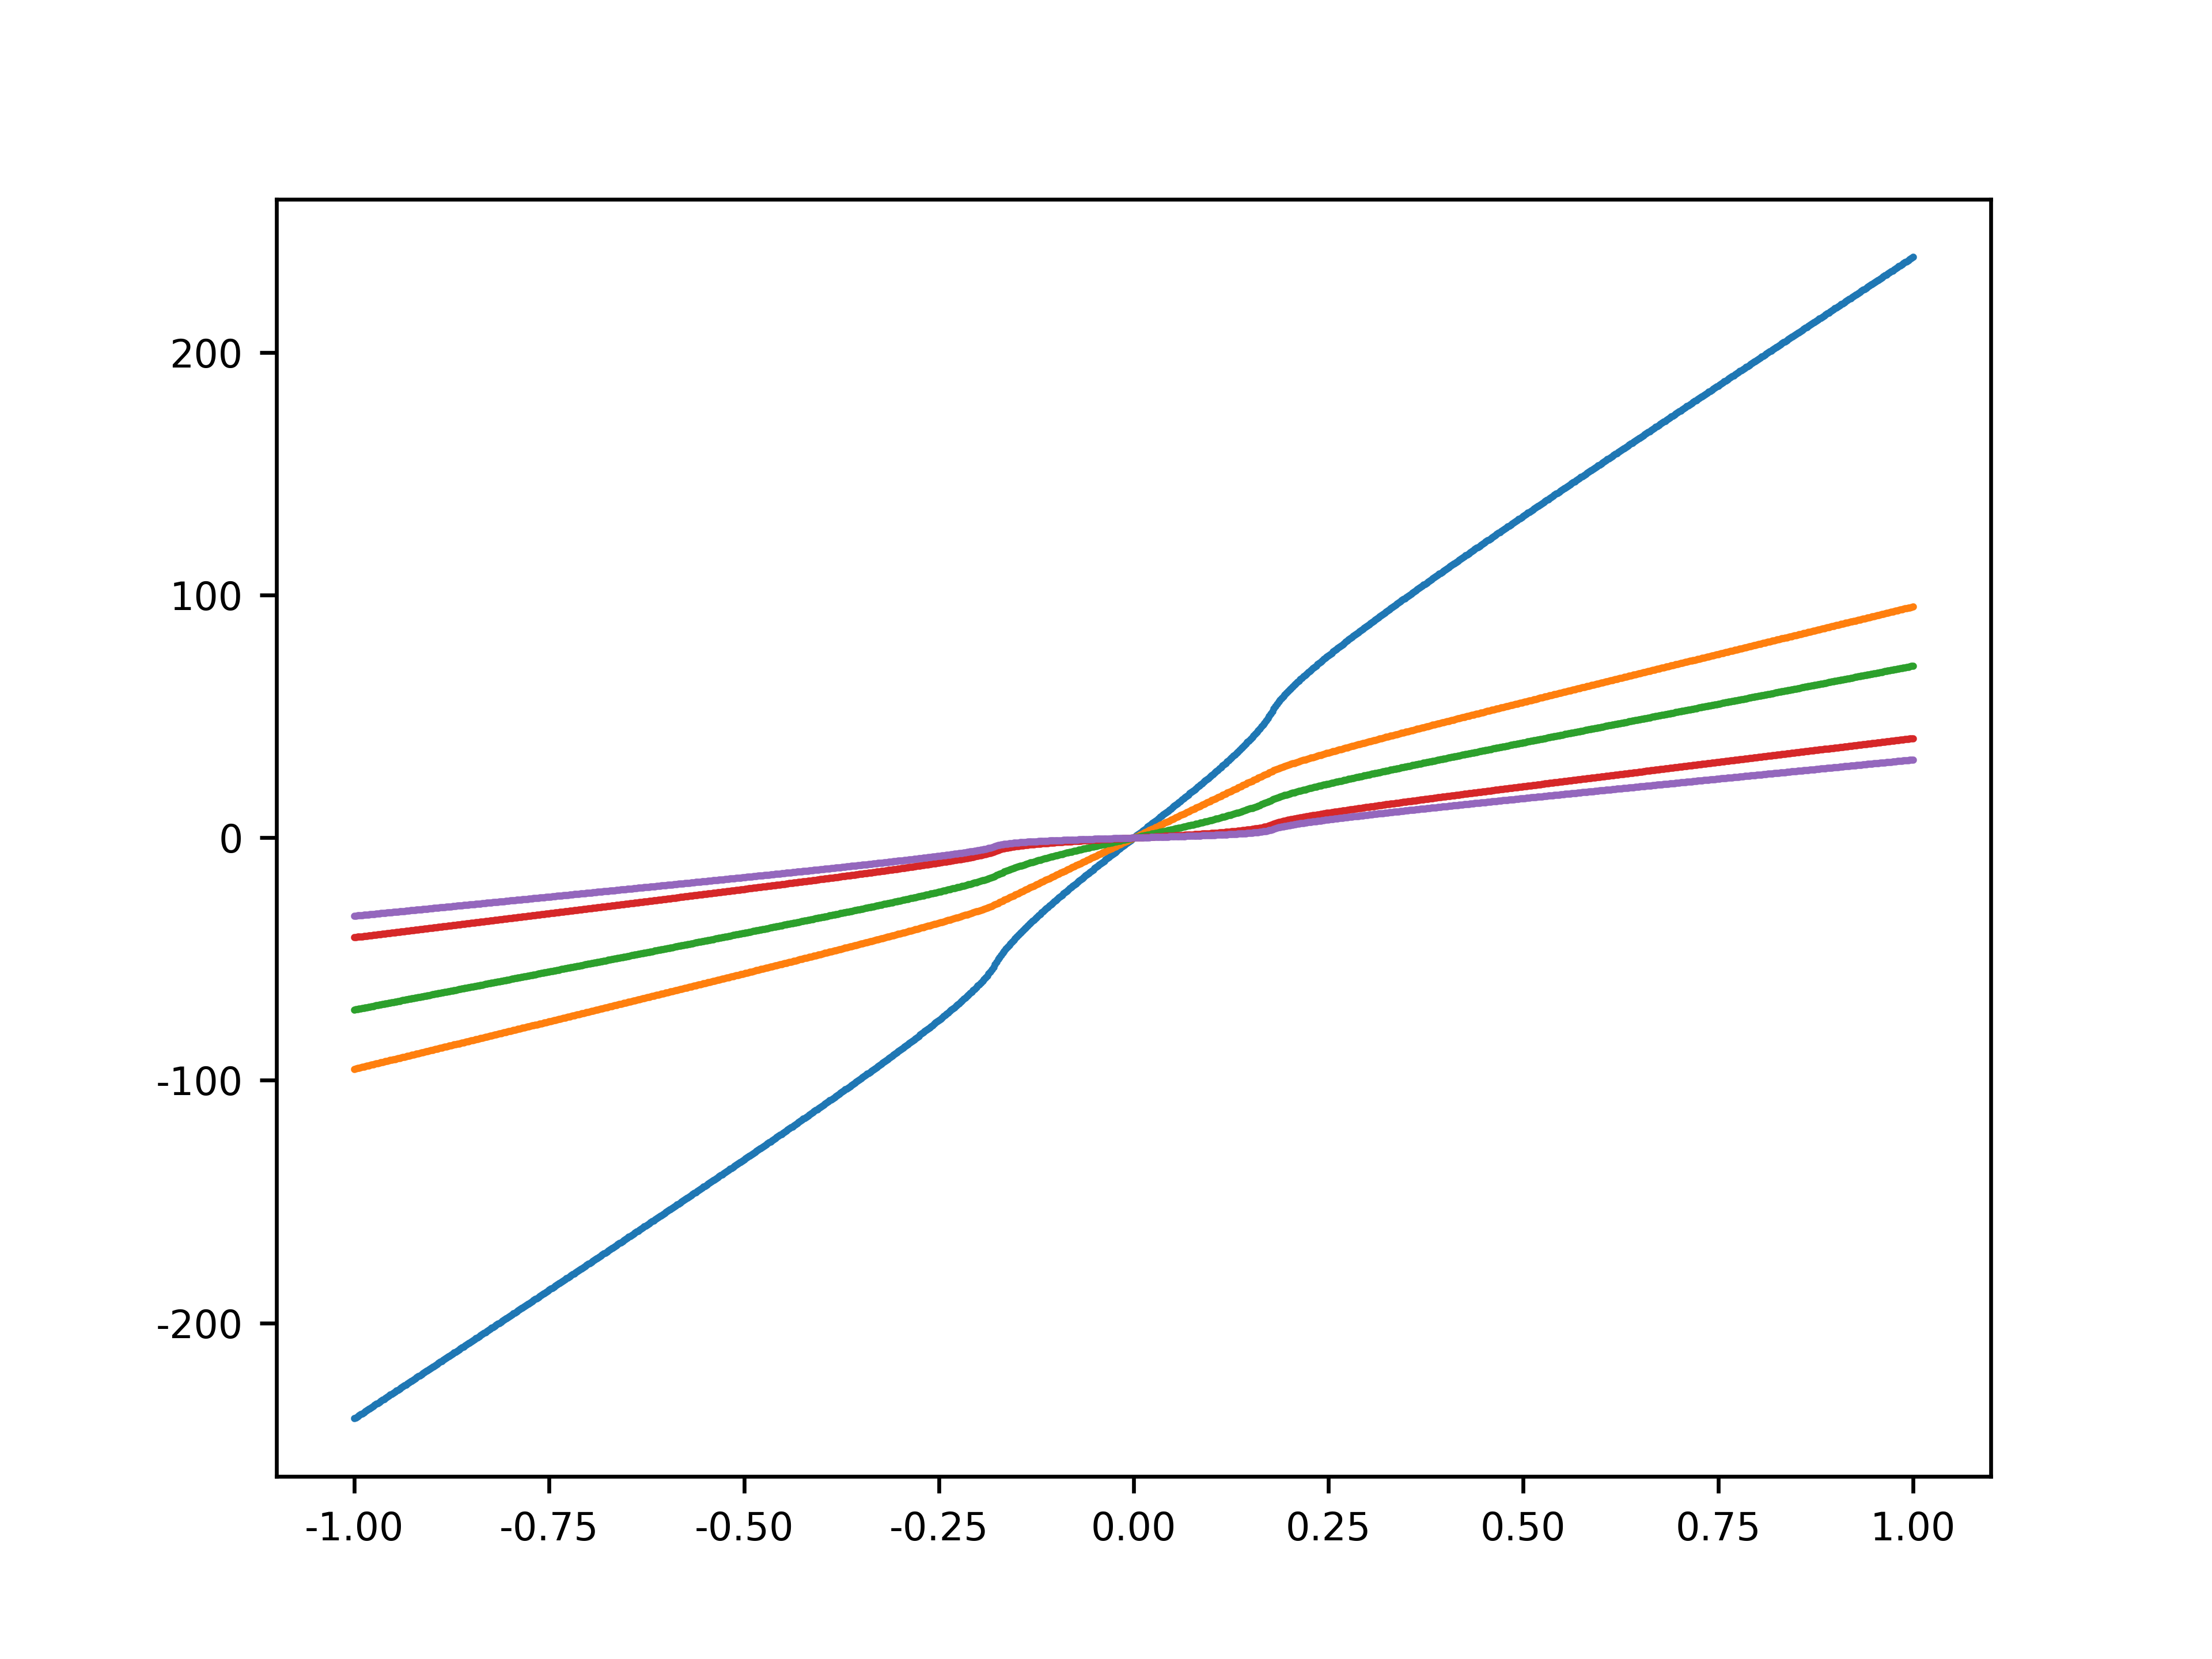

In [39]:
plt.plot(V_mV, I_nA, ".")
for i in range(np.shape(Ix_nA)[1]):
    plt.plot(V_mV, Ix_nA[:, i], ".")

In [ ]:
# R shunt
from superconductivity.evaluation import ShuntSpec, get_shunt_traces

spec = ShuntSpec(delta_mV=0.19, subgap_range=(0, 1.0), min_points=3)
shunts = get_shunt_traces(traces=traces, spec=spec, show_progress=True)

# shunts.Gshunt_uS
# shunts.Rshunt_MOhm

get_shunt:   0%|          | 0/143 [00:00<?, ?trace/s]

In [ ]:
# smoothing

from superconductivity.evaluation import get_smoothed_samplings, SmoothingSpec

importlib.reload(sys.modules["superconductivity.evaluation"])

smoothspec = SmoothingSpec(
    median_bins=5,
    sigma_bins=2.0,
)

smooth = get_smoothed_samplings(
    samplings=samples,
    spec=smoothspec,
)

In [ ]:
# data to fit
Vbias_mV = samples.Vbin_mV
Ibias_nA = samples.Ibin_nA
Iexp_nA = samples.I_nA
Vexp_mV = samples.V_mV
dGexp_G0 = samples.dG_G0
dRexp_R0 = samples.dR_R0

# Vbias_mV = smooth.Vbin_mV
# Ibias_nA = smooth.Ibin_nA
# Iexp_nA = smooth.I_nA
# Vexp_mV = smooth.V_mV
# dGexp_G0 = smooth.dG_G0
# dRexp_R0 = smooth.dR_R0

In [ ]:
from superconductivity.optimizers.gui import fit_gui

importlib.reload(sys.modules["superconductivity.optimizers.gui"])

fit_gui(V_mV=Vbias_mV, I_nA=Iexp_nA)

Starting Bokeh server version 3.9.0 (running on Tornado 6.5.5)
User authentication hooks NOT provided (default user enabled)


Launching server at http://localhost:65079


WebSocket connection opened
ServerConnection created


In [ ]:
import importlib
import superconductivity.optimizers.pat as pat

importlib.reload(pat)

solution = pat.fit_pats(
    V_mV=Vbias_mV,
    I_nA=Iexp_nA,
    show_progress=True,
)

PAT fits:   0%|          | 0/143 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
solution

{'V_mV': array([-1.6  , -1.598, -1.596, ...,  1.596,  1.598,  1.6  ], shape=(1601,)),
 'I_exp_nA': array([-23.06501673, -23.0499011 , -23.02907494, ...,  23.02724795,
         23.0503225 ,  23.06882552], shape=(1601,)),
 'I_ini_nA': array([-23.09115051, -23.06145666, -23.03175368, ...,  23.03175368,
         23.06145666,  23.09115051], shape=(1601,)),
 'I_fit_nA': array([-23.09473389, -23.06502643, -23.03531833, ...,  23.03531833,
         23.06502643,  23.09473389], shape=(1601,)),
 'params': (ParameterSpec(name='GN_G0', label='<i>G</i><sub>N</sub> (<i>G</i><sub>0</sub>)', lower=0.0, upper=10.0, guess=0.189, fixed=False, value=0.18904481882820662, error=2.016397302004575e-05),
  ParameterSpec(name='T_K', label='<i>T</i> (K)', lower=0.0, upper=1.5, guess=0.236, fixed=False, value=0.235959625419408, error=0.06703827168355521),
  ParameterSpec(name='Delta_meV', label='<i>Δ</i> (meV)', lower=0.18, upper=0.21, guess=0.195, fixed=False, value=0.1955424661339017, error=0.0003174170538638743)

In [ ]:
# Test fit one curve
from superconductivity.optimizers.old_pat.fit_pat import fit_I_nA
from superconductivity.optimizers.old_pat.show_fitting import show_fitting, show_stats

importlib.reload(sys.modules["superconductivity.optimizers.old_pat.fit_pat"])
importlib.reload(sys.modules["superconductivity.optimizers.old_pat.show_fitting"])

solution0 = fit_I_nA(
    V_mV=Vbias_mV,
    I_nA=Iexp_nA[0, :],
    G_N=(0.18907387255862304, (0.1, 0.3), False),
    T_K=(0.23393265069546368, (0.0, 1.0), False),
    Delta_meV=(0.1955352791293755, (0.180, 0.2), False),
    gamma_meV=(0.004379851077615499, (1e-4, 30e-3), False),
    model="dynes",
)
show_fitting(solution0, num=0)
show_stats(solution0)

ModuleNotFoundError: No module named 'superconductivity.optimizers.utilities'

In [ ]:
# fit the whole thing

I_fit_nA = np.full_like(Iexp_nA, np.nan, dtype="float64")
A_fit_mV = np.full_like(Aout_mV, np.nan, dtype="float64")
A_fit_err_mV = np.full_like(Aout_mV, np.nan, dtype="float64")
T_fit_K = np.full_like(Aout_mV, np.nan, dtype="float64")
T_fit_err_K = np.full_like(Aout_mV, np.nan, dtype="float64")

from superconductivity.optimizers.fit_pat import SolutionDict

solutions: list[SolutionDict] = []
for i, _ in enumerate(tqdm(Aout_mV)):
    if i > 1:
        a_mV = A_fit_mV[i - 1]
    else:
        a_mV = 0.0
    solution = fit_I_nA(
        V_mV=Vbias_mV,
        I_nA=Iexp_nA[i, :],
        G_N=(solution0["G_N"], (0.1, 0.3), True),
        T_K=(solution0["T_K"], (0.0, 1.2), False),
        Delta_meV=(solution0["Delta_mV"], (0.190, 0.2), True),
        gamma_meV=(solution0["gamma_mV"], (1e-4, 30e-3), True),
        A_mV=(a_mV, (0, 4), False),
        nu_GHz=(nu_GHz, (nu_GHz * 0.9, nu_GHz * 1.1), False),
        model="dynes+pat",
        optimizer="curve_fit",
    )
    I_fit_nA[i, :] = solution["I_fit_nA"]
    A_fit_mV[i] = solution["A_mV"]
    T_fit_K[i] = solution["T_K"]

    T_fit_err_K[i] = solution["perr"][1]
    A_fit_err_mV[i] = solution["perr"][4]
    solutions.append(solution)

100%|██████████| 101/101 [20:36<00:00, 12.24s/it]


In [ ]:
from scipy.optimize import curve_fit


def calibration_A(x_data, eta: float, A_off: float):
    A_cal = A_off + eta * x_data
    return A_cal


A_popt, A_pcov = curve_fit(
    f=calibration_A,
    xdata=np.array(Aout_mV, dtype="float64"),
    ydata=np.array(A_fit_mV, dtype="float64"),
)
A_perr = np.sqrt(np.diag(A_pcov))
A_popt

array([ 0.00084489, -0.00794814])

In [ ]:
# data to plot
nu_GHz = 18.3
eta = 0.00084489
Delta_meV = 0.1955424661339017

Vbias = Vbias_mV / Delta_meV
Abias = Aout_mV * (eta) / (sc.h_e_pVs * nu_GHz)
Ibias = Ibias_nA / (Delta_meV * GN_G0 * sc.G_0_muS)
Iexp = Iexp_nA / (Delta_meV * GN_G0 * sc.G_0_muS)
dGexp = dGexp_G0 / GN_G0
dRexp = dRexp_R0 * GN_G0

Aintrest = [0, 0.96586225, 1.93172449, 3.09075919, 4.05662144]

Vbiaslim = (-0.5, 4.5)
Abiaslim = (0, 5)
Ibiaslim = (-0.5, 4.5)
Ilim = (-0.05, 4.5)
dRlim = (-0.05, 4.5)
dGlim = (-0.05, 4.5)

Iexp = np.clip(Iexp, Ilim[0], Ilim[1])
# dGexp = np.where(dGexp > dGlim[1], 5, dGexp)
# dRexp = np.where(dRexp > dRlim[1], 5, dRexp)
dGexp = np.clip(dGexp, dGlim[0], dGlim[1])
dRexp = np.clip(dRexp, dRlim[0], dRlim[1])

Vlabel = r"$eV\,/\,\Delta_0$"
Alabel = r"$eA\,/\,h\nu$"
Ilabel = r"$eI\,/\,\Delta_0 G_\mathrm{N}$"
dGlabel = r"$\mathrm{d}I/\mathrm{d}V\,/\,G_\mathrm{N}$"
dRlabel = r"$\mathrm{d}V/\mathrm{d}I\,/\,R_\mathrm{N}$"

Vbiasticks = [0, 2, 4]
Abiasticks = [0, 2, 4]
Ibiasticks = [0, 2, 4]
Iticks = [0, 2, 4]
dGticks = [0, 2, 4]
dRticks = [0, 2, 4]

Vbiasticklabels = None
Abiasticklabels = None
Ibiasticklabels = None
Iticklabels = None
dGticklabels = None
dRticklabels = None

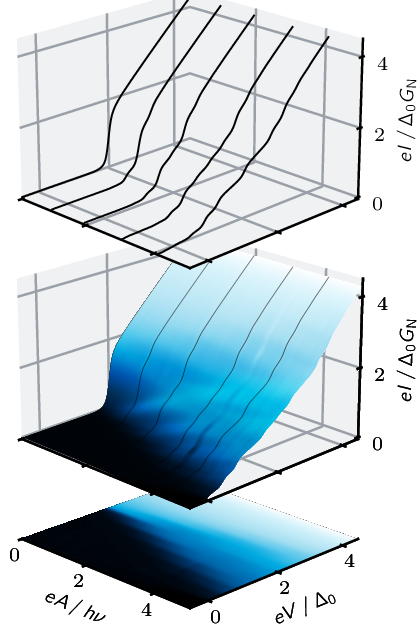

/Users/oliver/Documents/cryolab/superconductivity/thesis/results/tunnelbarrier/1_raw_iv/main.png

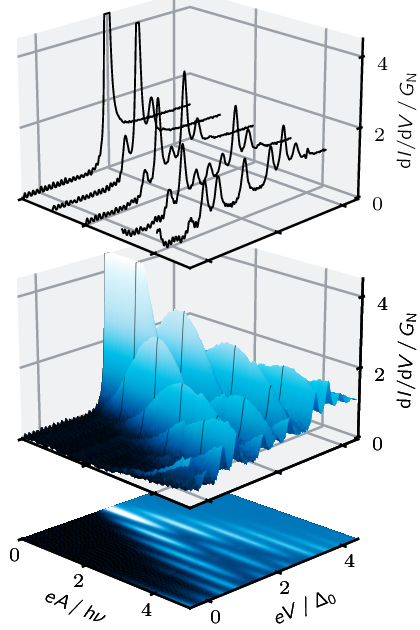

/Users/oliver/Documents/cryolab/superconductivity/thesis/results/tunnelbarrier/1_raw_didv/main.png

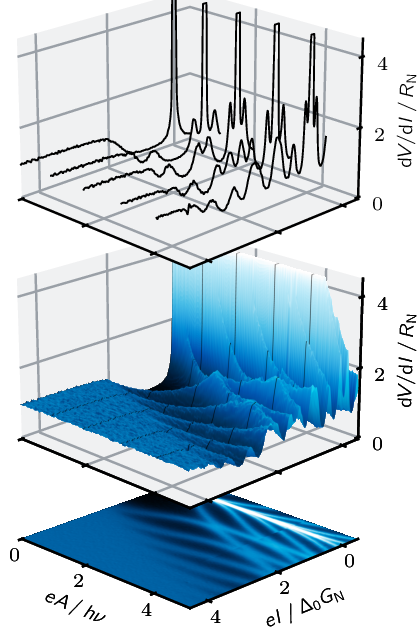

/Users/oliver/Documents/cryolab/superconductivity/thesis/results/tunnelbarrier/1_raw_dvdi/main.png

In [ ]:
# plot the data

import superconductivity.visuals.thesis.latex as thesis_latex

importlib.reload(thesis_latex)
export_stacked_waterfall_thesis = thesis_latex.export_stacked_waterfall_thesis

to_plot = (True, True, True)
# to_plot = (False, True, False)
sub_dir = "results/tunnelbarrier/"
name = "1_raw"

# region setting
figsize = (2.1, 3.15)
subfigsize = (2.1, 2.1)
posx = (0, 0, 0)
posy = (1.6, 0.4, -0.1)
waterfall_traces = Aintrest
box_aspect = (1, 1, np.sqrt(2) / 2)
azim = 315 - 90
axes_rect = (0.0, 0.0, 1.85, 1.85)
x_axis = (False, False, True)
y_axis = (False, False, True)
labelspacing = (0.5, 0.5, 0.45)
ticklabelspacing = (0.35, 0.35, 0.5)
heatmap_cell_overlap = 0.7
z_axis_side = "right"
surface_x_oversample = 10
# endregion


# region plotting
if to_plot[0]:
    export = export_stacked_waterfall_thesis(
        x=Vbias,
        y=Abias,
        z=Iexp,
        name=f"{name}_iv",
        sub_dir=sub_dir,
        xlabel=Vlabel,
        ylabel=Alabel,
        zlabel=Ilabel,
        figsize=figsize,
        subfigsize=subfigsize,
        waterfall_traces=waterfall_traces,
        box_aspect=box_aspect,
        azim=azim,
        xlim=Vbiaslim,
        ylim=Abiaslim,
        zlim=Ilim,
        z_axis_side=z_axis_side,
        axes_rect=axes_rect,
        x_axis=x_axis,
        y_axis=y_axis,
        posx=posx,
        posy=posy,
        ticks=(Vbiasticks, Abiasticks, Iticks),
        ticklabels=(Vbiasticklabels, Abiasticklabels, Iticklabels),
        labelspacing=labelspacing,
        ticklabelspacing=ticklabelspacing,
        surface_x_oversample=surface_x_oversample,
    )

if to_plot[1]:
    export = export_stacked_waterfall_thesis(
        x=Vbias,
        y=Abias,
        z=dGexp,
        name=f"{name}_didv",
        sub_dir=sub_dir,
        xlabel=Vlabel,
        ylabel=Alabel,
        zlabel=dGlabel,
        figsize=figsize,
        subfigsize=subfigsize,
        waterfall_traces=waterfall_traces,
        box_aspect=box_aspect,
        azim=azim,
        xlim=Vbiaslim,
        ylim=Abiaslim,
        zlim=dGlim,
        z_axis_side=z_axis_side,
        axes_rect=axes_rect,
        x_axis=x_axis,
        y_axis=y_axis,
        posx=posx,
        posy=posy,
        ticks=(Vbiasticks, Abiasticks, dGticks),
        ticklabels=(Vbiasticklabels, Abiasticklabels, dGticklabels),
        labelspacing=labelspacing,
        ticklabelspacing=ticklabelspacing,
        surface_x_oversample=surface_x_oversample,
    )

if to_plot[2]:
    export = export_stacked_waterfall_thesis(
        x=Ibias,
        y=Abias,
        z=dRexp,
        name=f"{name}_dvdi",
        invert_xaxis=True,
        sub_dir=sub_dir,
        xlabel=Ilabel,
        ylabel=Alabel,
        zlabel=dRlabel,
        figsize=figsize,
        subfigsize=subfigsize,
        waterfall_traces=waterfall_traces,
        box_aspect=box_aspect,
        azim=azim,
        xlim=Ibiaslim,
        ylim=Abiaslim,
        zlim=dRlim,
        z_axis_side=z_axis_side,
        axes_rect=axes_rect,
        x_axis=x_axis,
        y_axis=y_axis,
        posx=posx,
        posy=posy,
        ticks=(Ibiasticks, Abiasticks, dRticks),
        ticklabels=(Ibiasticklabels, Abiasticklabels, dRticklabels),
        labelspacing=labelspacing,
        ticklabelspacing=ticklabelspacing,
        surface_x_oversample=surface_x_oversample,
    )
# endregion